<div align="center">

# Teoría de Circuitos 2

##Trabajo Práctico N°0

**Estudiante:** Nahir Lewartowski

</div>

---

## Función de Transferencia, Módulo, Fase y Polos/Ceros

### Análisis Nodal
Aplicando el modelo de amplificador operacional ideal ($V_+ = V_-$ e $I_{in} = 0$), calculo la tensión en el nodo no inversor usando el divisor de tensión entre el capacitor y la resistencia:

$$V_+ = V_1 \cdot \frac{R_3}{R_3 + \frac{1}{sC_1}} = V_1 \cdot \frac{sR_3C_1}{sR_3C_1 + 1}$$

Planteo la Ley de Corrientes de Kirchhoff en el nodo inversor:

$$\frac{V_1 - V_-}{R_1} + \frac{V_2 - V_-}{R_2} = 0$$

Despejo $V_2$:

$$V_2 = V_- \left( 1 + \frac{R_2}{R_1} \right) - V_1 \left( \frac{R_2}{R_1} \right)$$

Sustituyo $V_-$ y simplifico para obtener la función de transferencia:

$$H(s) = \frac{V_2}{V_1} = \frac{sR_3C_1 - \frac{R_2}{R_1}}{sR_3C_1 + 1}$$

### Módulo y Fase
Asumiendo la condición de diseño **$R_1 = R_2$**, la transferencia se simplifica a la de un Filtro Pasa-Todo de primer orden:

$$H(s) = \frac{sR_3C_1 - 1}{sR_3C_1 + 1}$$


* **Módulo:**
  $$|H(j\omega)| = \frac{\sqrt{(-1)^2 + (\omega R_3C_1)^2}}{\sqrt{1^2 + (\omega R_3C_1)^2}} = 1$$
  
* **Fase:**
  $$\phi(\omega) = 180^\circ - \text{arctg}(\omega R_3C_1) - \text{arctg}(\omega R_3C_1)$$

### Diagrama de Polos y Ceros
* **Cero:** $s_z = \frac{1}{R_3C_1}$ (Semiplano derecho)
* **Polo:** $s_p = -\frac{1}{R_3C_1}$ (Semiplano izquierdo)

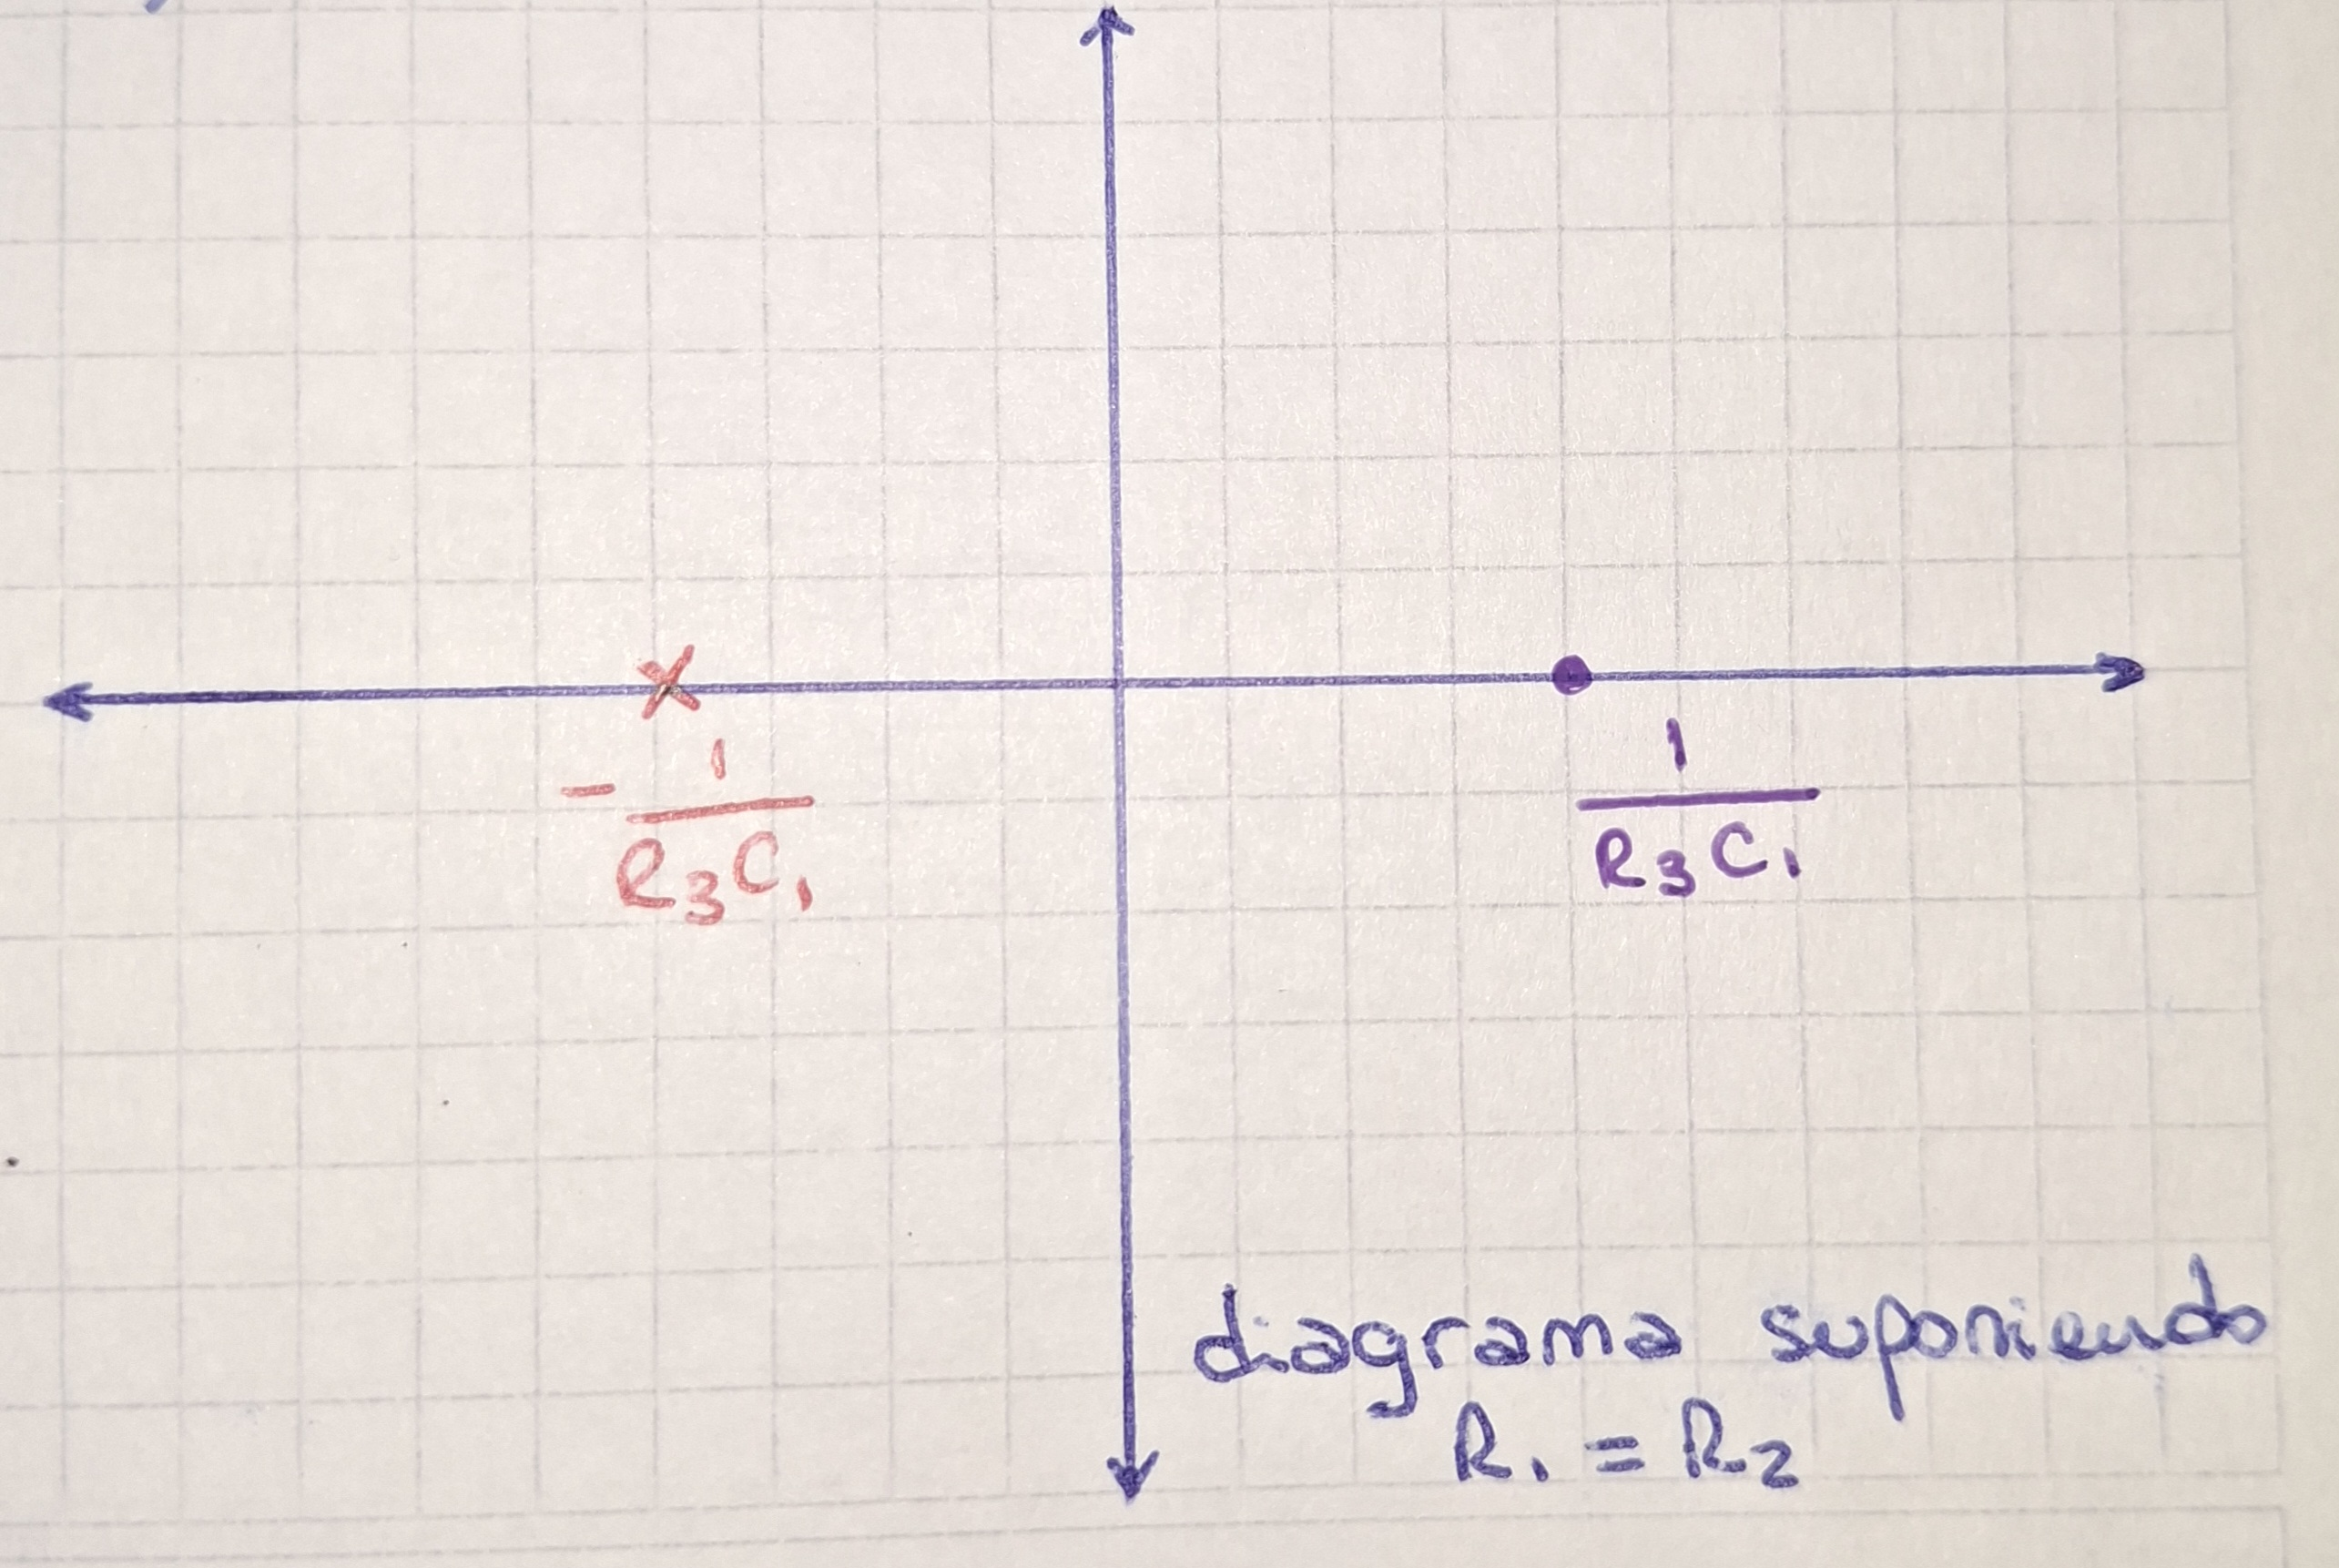

## 2. Normalización de la Transferencia

* **Norma de Impedancia ($Z_n$):**  $R_3$.
* **Norma de Frecuencia ($\omega_n$):**  $\omega_0 = \frac{1}{R_3C_1}$.

Variable compleja normalizada: $S = \frac{s}{\omega_n} = s R_3 C_1$.

$$H(S) = \frac{S - 1}{S + 1}$$

### Red Normalizada

* $R'_3 = \frac{R_3}{Z_n} = \frac{R_3}{R_3} = 1$

* $C'_1 = C_1 \cdot Z_n \cdot \omega_n = C_1 \cdot R_3 \cdot \frac{1}{R_3C_1} = 1$

* $R'_1 = \frac{R_1}{Z_n} = \frac{R_1}{R_3}$

* $R'_2 = \frac{R_2}{Z_n} = \frac{R_2}{R_3}$



## 3. Simulación con Python

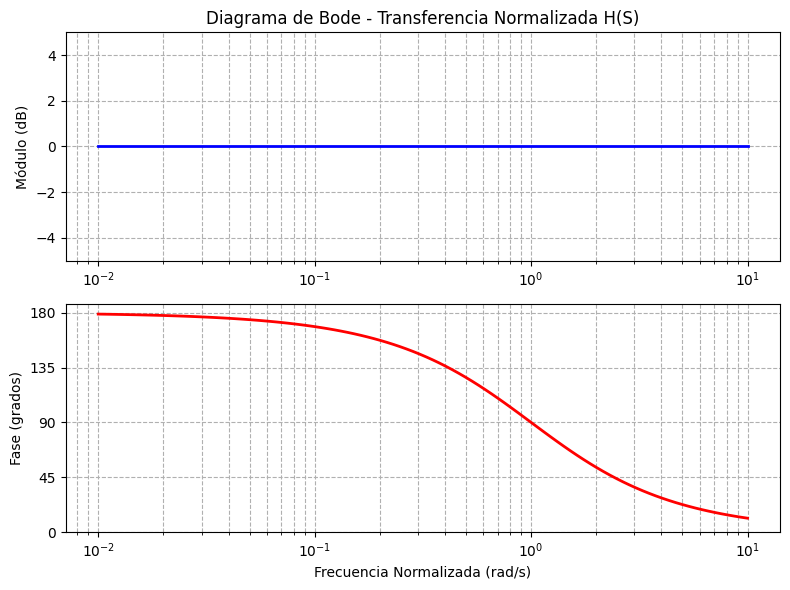

In [1]:
import scipy.signal as signal
import matplotlib.pyplot as plt
import numpy as np

num = [1, -1]

den = [1, 1]

sistema = signal.TransferFunction(num, den)

# Diagrama de Bode
w, mag, fase = signal.bode(sistema)

fig, (grafico_modulo, grafico_fase) = plt.subplots(2, 1, figsize=(8, 6))

grafico_modulo.semilogx(w, mag, color='blue', linewidth=2)
grafico_modulo.set_title('Diagrama de Bode - Transferencia Normalizada H(S)')
grafico_modulo.set_ylabel('Módulo (dB)')
grafico_modulo.grid(True, which="both", ls="--") # Agregamos la grilla
grafico_modulo.set_ylim(-5, 5) # Forzamos el eje Y para que se vea bien el 0 dB

grafico_fase.semilogx(w, fase, color='red', linewidth=2)
grafico_fase.set_xlabel('Frecuencia Normalizada (rad/s)')
grafico_fase.set_ylabel('Fase (grados)')
grafico_fase.grid(True, which="both", ls="--")
grafico_fase.set_yticks([180, 135, 90, 45, 0]) # Marcamos los ángulos importantes

plt.tight_layout()
plt.show()

## 4. Simulación en LTSpice
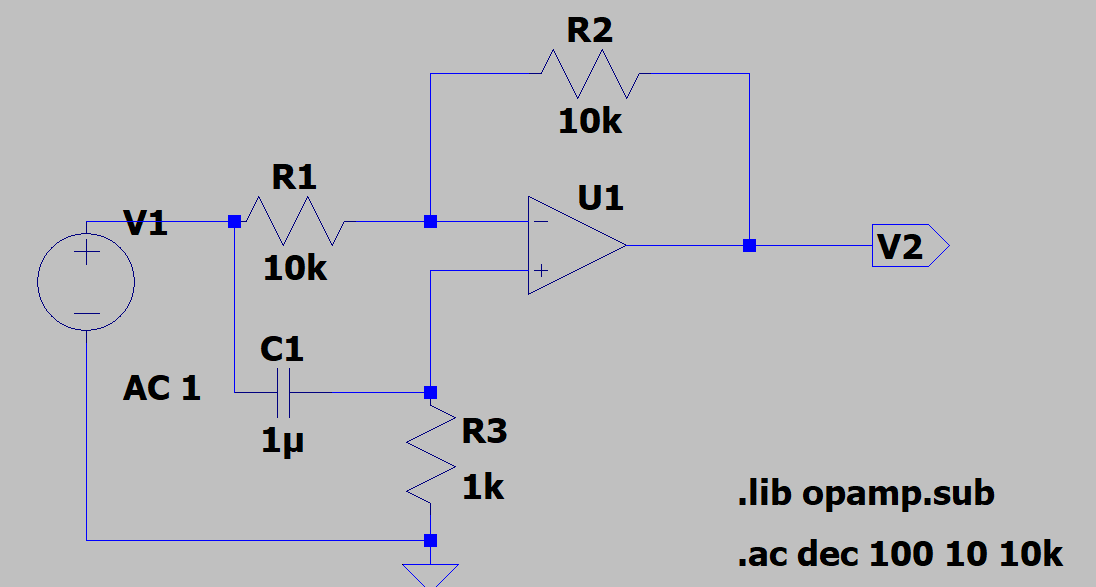
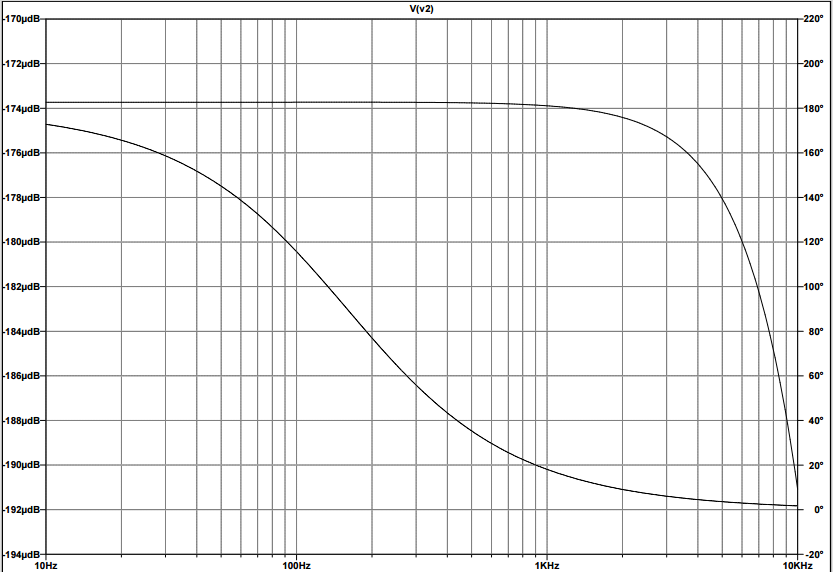

## 5. Tipo de filtro

Que el módulo de la función transferencia sea 1 independientemente de la frecuencia implica que es un pasa-todo, no amplifica ni atenúa ninguna frecuencia, solo desfasa.
El MF-103 implementa en cascada el mismo circuito analizado, así que las funciones transferencia son iguales.

## Sympy


In [10]:
import sympy as sp
from IPython.display import display, Math

s, S, R1, R2, V1, V2 = sp.symbols('s S R1 R2 V1 V2')
w, R3, C1 = sp.symbols('omega R3 C1', real=True, positive=True)

V_mas = V1 * R3 / (R3 + 1/(s*C1))
ecuacion_nodos = sp.Eq((V1 - V_mas)/R1 + (V2 - V_mas)/R2, 0)
solucion_V2 = sp.solve(ecuacion_nodos, V2)[0]

H_s_generica = sp.simplify(solucion_V2 / V1)
print("Función de Transferencia Genérica H(s):")
display(H_s_generica)

H_s = sp.simplify(H_s_generica.subs(R2, R1))
print("\nFunción de Transferencia Pasa-Todo (R1 = R2):")
display(H_s)

print("\n ")
numerador, denominador = sp.fraction(H_s)
cero = sp.solve(numerador, s)
polo = sp.solve(denominador, s)
display(Math(r'\text{Cero: } s_z = ' + sp.latex(cero[0])))
print("\n")
display(Math(r'\text{Polo: } s_p = ' + sp.latex(polo[0])))

print("\n")
H_jw = H_s.subs(s, sp.I * w)
modulo = sp.simplify(sp.Abs(H_jw))
display(Math(r'\text{Módulo } |H(j\omega)| = ' + sp.latex(modulo)))
print("\n")
fase = sp.arg(H_jw)
display(Math(r'\text{Fase } \phi(\omega) = ' + sp.latex(fase)))

print("\n")
H_S_norm = sp.simplify(H_s.subs(s, S / (R3*C1)))
display(Math(r'\text{Transferencia Normalizada } H(S) = ' + sp.latex(H_S_norm)))

Función de Transferencia Genérica H(s):


(C1*R1*R3*s - R2)/(R1*(C1*R3*s + 1))


Función de Transferencia Pasa-Todo (R1 = R2):


(C1*R3*s - 1)/(C1*R3*s + 1)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Análisis TP1-Ej7
Ambos circuitos son filtros pasa-todo; las topologías son muy similares: un divisor resistivo que toma una muestra de la entrada y la realimenta negativamente. La frecuencia central es $\omega_0 = \frac{1}{RC}$.
La red de la izquierda es de 1er orden, barre la fase un total de 180º. Al igual que el circuito previamente analizado, $R_1/R_2=1$ para que los polos y ceros queden simétricos, y por ende el módulo sea 1.
La derecha es de 2do orden, barre la fase un total de 360º pero $R_A/R_B=5$ para que los polos y ceros resulten simétricos, modificando así el módulo.
